# Brain Tumor Segmentation
### Problem Statement:
Manual segmentation of brain tumors is a meticu lous task performed by radiologists, which is time consuming and prone to inter-observer variability. In clinical practice, high precision is required to ensure effective treatment. However, processing 3D medical images presents significant computational challenges due to high dimensionality and class imbalance. Furthermore, to be adopted in clinical workflows, these models must demonstrate transparency in their diagnostic outputs.

### Data:
The project will utilize the [BraTS 2021](https://www.kaggle.com/datasets/dschettler8845/brats-2021-task1/data) Task 1
Database, which contains 3D MRI scans for 1,251
subjects.

### Objective:
* Develop a 3D Deep Learning Model to pre
dict voxel-wise segmentation masks from volumet
ric MRI data.
* Classify brain tissue into four categories: healthy
tissue, necrotic core, peritumoral edema, and en
hancing tumor.
* Evaluate the model using standardized clinical
metrics and visualize results to ensure anatomical
accuracy

### Expected Outcomes:
* High segmentation accuracy across all target re
gions (Whole Tumor, Tumor Core, and Enhancing
Tumor).
* A reliable, automated pipeline to assist in clinical
decision-making.

### Install Requirted packages...
We used python 3.12.10, pytorch 2.10.0 opencv-python 4.13, scikit-image 0.26.0,  scikit-learn 1.6.1, matplotlib 3.10.8, pandas 3.0.1.

We use **MONAI**, a PyTorch-based framework purpose-built for medical image analysis. It provides 3D transforms, volumetric data loaders, segmentation architectures, and clinical metrics out of the box.

## Environment

| Package | Version | Purpose |
|---|---|---|
| **Python** | 3.12.10 | Programming language |
| **torch** | 2.10.0 | Deep learning framework (3D U-Net, Attention U-Net, Swin UNETR) |
| **torchvision** | 0.25.0 | Vision utilities, paired with torch |
| **torchaudio** | 2.10.0 | Audio utilities, paired with torch |
| **CUDA** | 13.0 | GPU acceleration backend |
| **monai** | >=1.4 (all) | Medical image segmentation models, transforms, losses |
| **nibabel** | latest | Loading NIfTI (.nii.gz) MRI volumes from BraTS 2021 |
| **matplotlib** | 3.10.8 | Visualization of MRI slices and training curves |
| **numpy** | latest | Numerical array operations |
| **pandas** | 3.0.1 | Data management and results logging |
| **scikit-learn** | 1.6.1 | Evaluation metrics and data splitting |
| **tqdm** | latest | Progress bars for training loops |
| **tensorboard** | latest | Training metrics logging and visualization |


## Importing Libraries

In [1]:
import os
import sys
import glob
import time
import platform
import random
import warnings
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

import monai
from monai.data import Dataset, DataLoader, decollate_batch, CacheDataset
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    NormalizeIntensityd,
    CropForegroundd,
    RandSpatialCropd,
    RandFlipd,
    RandRotate90d,
    RandScaleIntensityd,
    RandShiftIntensityd,
    EnsureTyped,
    Activationsd,
    AsDiscreted,
)
from monai.networks.nets import UNet, AttentionUnet, SwinUNETR
from monai.losses import DiceLoss, DiceCELoss
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.inferers import sliding_window_inference
from monai.utils import set_determinism

warnings.filterwarnings("ignore")

print(f"Python:   {sys.version}")
print(f"Platform: {platform.system()} {platform.release()}")
print(f"PyTorch:  {torch.__version__}")
print(f"MONAI:    {monai.__version__}")
print(f"CUDA:     {torch.cuda.is_available()} "
      f"({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'})")

Python:   3.12.1 | packaged by Anaconda, Inc. | (main, Jan 19 2024, 15:44:08) [MSC v.1916 64 bit (AMD64)]
Platform: Windows 11
PyTorch:  2.10.0+cu130
MONAI:    1.5.2
CUDA:     True (NVIDIA GeForce RTX 5070 Ti Laptop GPU)


## Configuration & Reproducibility
All hyperparameters live in one dictionary so you can tweak them without hunting through the notebook.

In [3]:
set_determinism(seed=42)

CONFIG = {
    # ── Paths ──────────────────────────────────────────────────
    # UPDATE this to your local BraTS 2021 dataset root
    "data_dir":    "data/brats2021",
    "output_dir":  "./outputs",

    # ── Training ──────────────────────────────────────────────
    "max_epochs":     100,
    "batch_size":     2,       # reduce to 1 if GPU memory is tight
    "learning_rate":  1e-4,
    "weight_decay":   1e-5,
    "val_interval":   2,       # run validation every N epochs
    "patience":       15,      # early-stopping patience (in val intervals)

    # ── Data ──────────────────────────────────────────────────
    "roi_size":       (128, 128, 128),  # 3D crop/patch size
    "num_workers":    0,      # Use 0 on Windows, 4 on Linux.
    "cache_rate":     0.1,     # fraction of data to cache in RAM (set 1.0 if RAM allows)

    # ── Model ─────────────────────────────────────────────────
    "in_channels":    4,       # T1, T1ce, T2, FLAIR
    "num_classes":    4,       # background + 3 tumor sub-regions
    "model_name":     "unet",  # options: "unet", "attention_unet", "swin_unetr"
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)

### Discover & Organize Data Paths

BraTS 2021 stores each subject in its own folder with four MRI modality files and one segmentation mask:

```
BraTS2021_00000/
    BraTS2021_00000_t1.nii.gz
    BraTS2021_00000_t1ce.nii.gz
    BraTS2021_00000_t2.nii.gz
    BraTS2021_00000_flair.nii.gz
    BraTS2021_00000_seg.nii.gz
```

We build a list of dictionaries — one per subject — that MONAI's data pipeline can consume directly.

In [4]:
def build_file_list(data_dir: str) -> list[dict]:
    """Scan data_dir and return a list of dicts with keys:
       't1', 't1ce', 't2', 'flair', 'seg' — each mapping to a file path."""
    subjects = sorted(glob.glob(os.path.join(data_dir, "BraTS2021_*")))
    data_dicts = []
    for subj in subjects:
        subj_id = os.path.basename(subj)
        entry = {
            "t1":    os.path.join(subj, f"{subj_id}_t1.nii.gz"),
            "t1ce":  os.path.join(subj, f"{subj_id}_t1ce.nii.gz"),
            "t2":    os.path.join(subj, f"{subj_id}_t2.nii.gz"),
            "flair": os.path.join(subj, f"{subj_id}_flair.nii.gz"),
            "seg":   os.path.join(subj, f"{subj_id}_seg.nii.gz"),
        }
        # Sanity check — all files must exist
        if all(os.path.isfile(v) for v in entry.values()):
            data_dicts.append(entry)
        else:
            print(f"Warning: Skipping {subj_id} — missing files")
    return data_dicts

all_data = build_file_list(CONFIG["data_dir"])
print(f"Total subjects found: {len(all_data)}")

Total subjects found: 1251


### Train / Validation / Test Split (80 / 10 / 10)

We use random splitting (deterministic via seed). With 1,251 subjects this gives roughly 1,000 / 125 / 126.

In [5]:
train_val_data, test_data = train_test_split(all_data, test_size=0.10, random_state=42)
train_data, val_data = train_test_split(train_val_data, test_size=0.1111, random_state=42)
# 0.1111 of 90% is approx 10% of total

print(f"Train : {len(train_data)} subjects")
print(f"Val   : {len(val_data)} subjects")
print(f"Test  : {len(test_data)} subjects")

Train : 1000 subjects
Val   : 125 subjects
Test  : 126 subjects


### Explore a Single Subject

Before building the pipeline, let's look at the raw data: shapes, voxel sizes, intensity ranges, and label distributions. This helps verify the data is loaded correctly.

In [6]:
sample = all_data[0]

print("=== Sample Subject ===")
for key in ["t1", "t1ce", "t2", "flair", "seg"]:
    img = nib.load(sample[key])
    data = img.get_fdata()
    print(f"{key:>5s}  shape={str(data.shape):>20s}  "
          f"dtype={str(data.dtype):>10s}  "
          f"range=[{data.min():.1f}, {data.max():.1f}]  "
          f"voxel_size={np.array(img.header.get_zooms()[:3]).round(2)}")

# Label distribution
seg = nib.load(sample["seg"]).get_fdata()
unique, counts = np.unique(seg, return_counts=True)
print("\nLabel distribution:")
label_names = {0: "Background", 1: "NCR/NET", 2: "Edema", 4: "Enhancing"}
for u, c in zip(unique, counts):
    pct = 100.0 * c / seg.size
    print(f"  Label {int(u)} ({label_names.get(int(u), '?'):>12s}): "
          f"{c:>10,} voxels ({pct:.2f}%)")

=== Sample Subject ===
   t1  shape=     (240, 240, 155)  dtype=   float64  range=[0.0, 2023.0]  voxel_size=[1. 1. 1.]
 t1ce  shape=     (240, 240, 155)  dtype=   float64  range=[0.0, 12343.0]  voxel_size=[1. 1. 1.]
   t2  shape=     (240, 240, 155)  dtype=   float64  range=[0.0, 2421.0]  voxel_size=[1. 1. 1.]
flair  shape=     (240, 240, 155)  dtype=   float64  range=[0.0, 2934.0]  voxel_size=[1. 1. 1.]
  seg  shape=     (240, 240, 155)  dtype=   float64  range=[0.0, 4.0]  voxel_size=[1. 1. 1.]

Label distribution:
  Label 0 (  Background):  8,870,695 voxels (99.36%)
  Label 1 (     NCR/NET):     11,738 voxels (0.13%)
  Label 2 (       Edema):     12,836 voxels (0.14%)
  Label 4 (   Enhancing):     32,731 voxels (0.37%)


### Visualize Raw MRI Slices + Segmentation Overlay

Display the four MRI modalities and the ground-truth segmentation mask at the axial slice with the most tumor content. This gives an intuitive sense of what each modality highlights.

- **T1/T1ce:** Structural detail, tumor core visibility
- **T2/FLAIR:** Best for identifying peritumoral edema
- **Colors:** Red = NCR/NET, Green = Edema, Yellow = Enhancing tumor

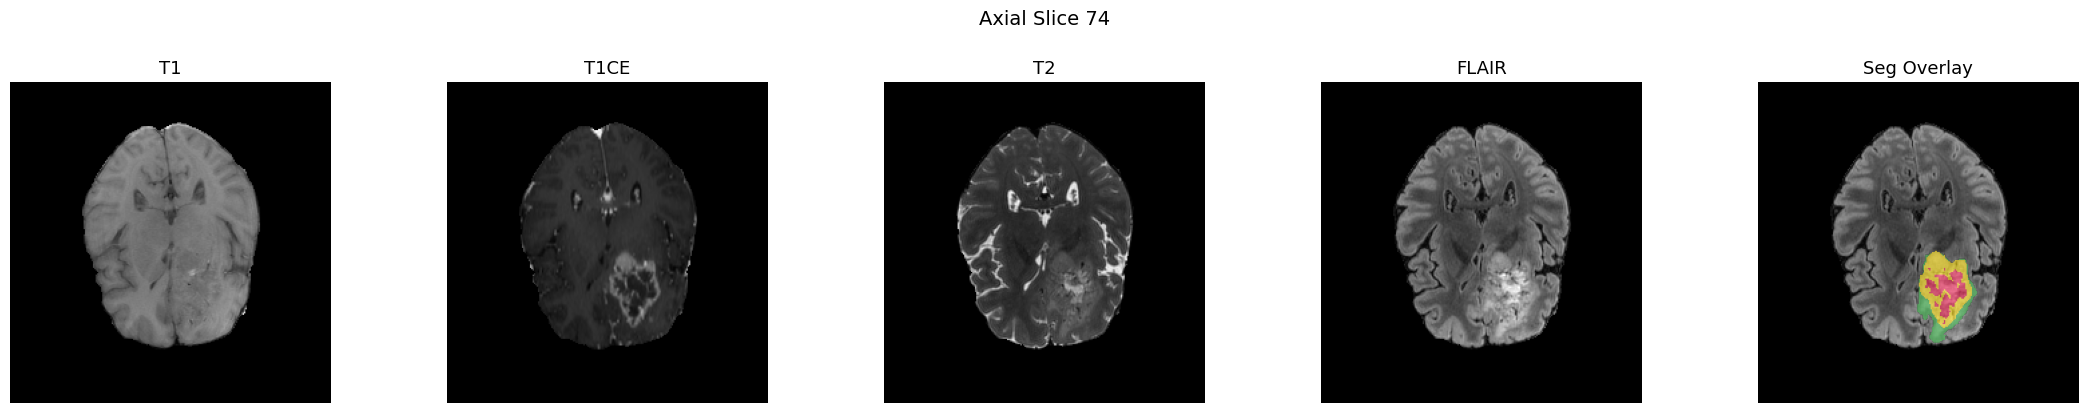

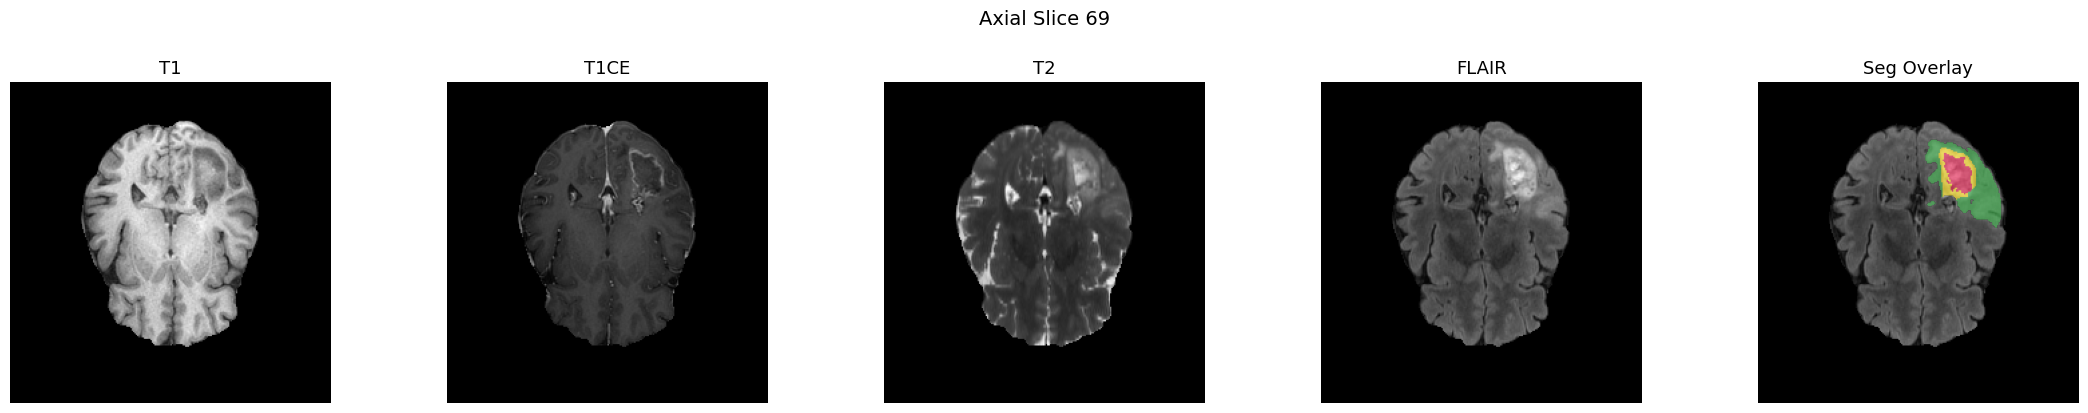

In [7]:
def visualize_subject(subject_dict: dict, slice_idx: int | None = None):
    """Plot 4 MRI modalities + segmentation overlay for one subject."""
    modalities = ["t1", "t1ce", "t2", "flair"]
    images = {k: nib.load(subject_dict[k]).get_fdata() for k in modalities}
    seg = nib.load(subject_dict["seg"]).get_fdata()

    if slice_idx is None:
        # Find axial slice with maximum tumor content
        tumor_per_slice = (seg > 0).sum(axis=(0, 1))
        slice_idx = int(np.argmax(tumor_per_slice))

    seg_cmap = ListedColormap(["none", "#e6194b", "#3cb44b", "black", "#ffe119"])

    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    for ax, mod in zip(axes[:4], modalities):
        ax.imshow(images[mod][:, :, slice_idx].T, cmap="gray", origin="lower")
        ax.set_title(mod.upper(), fontsize=13)
        ax.axis("off")

    # Overlay: FLAIR + segmentation
    axes[4].imshow(images["flair"][:, :, slice_idx].T, cmap="gray", origin="lower")
    seg_masked = np.ma.masked_where(
        seg[:, :, slice_idx].T == 0, seg[:, :, slice_idx].T
    )
    axes[4].imshow(seg_masked, cmap=seg_cmap, alpha=0.6, origin="lower", vmin=0, vmax=4)
    axes[4].set_title("Seg Overlay", fontsize=13)
    axes[4].axis("off")

    plt.suptitle(f"Axial Slice {slice_idx}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Visualize two different subjects
visualize_subject(all_data[0])
visualize_subject(all_data[10])

### Custom Transform: Remap BraTS Labels

BraTS uses labels `{0, 1, 2, 4}` — label 3 is absent. We remap them to contiguous class indices `{0, 1, 2, 3}` so that standard cross-entropy and softmax (which expect classes 0..N-1) work correctly.

| Original | Remapped | Region |
|----------|----------|--------|
| 0 | 0 | Background |
| 1 | 1 | NCR/NET |
| 2 | 2 | Edema |
| 4 | 3 | Enhancing |

In [8]:
class ConvertBraTSLabels(monai.transforms.MapTransform):
    """Remap BraTS labels {0,1,2,4} -> {0,1,2,3}."""

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key] = d[key].clone() if isinstance(d[key], torch.Tensor) else d[key].copy()
            d[key][d[key] == 4] = 3
        return d

print("ConvertBraTSLabels transform defined.")

ConvertBraTSLabels transform defined.


### Custom Transform: Stack Modalities

The four MRI modalities are loaded as separate dictionary keys. We stack them into a single `(4, D, H, W)` tensor under the key `"image"`, and squeeze the segmentation to `(D, H, W)` integer labels.

In [9]:
class StackModalities(monai.transforms.MapTransform):
    """Stack T1, T1ce, T2, FLAIR into a single 4-channel volume under key 'image'.
       Also convert seg from (1,D,H,W) to (D,H,W) integer labels."""

    def __init__(self, image_keys, seg_key="seg"):
        super().__init__(keys=image_keys)
        self.image_keys = image_keys
        self.seg_key = seg_key

    def __call__(self, data):
        d = dict(data)
        # Stack: each modality is (1, D, H, W) -> combined (4, D, H, W)
        d["image"] = torch.cat([d[k] for k in self.image_keys], dim=0)
        # Seg: (1, D, H, W) -> (D, H, W) as long tensor
        d["seg"] = d[self.seg_key][0].long()
        # Remove individual modality keys
        for k in self.image_keys:
            del d[k]
        return d

print("StackModalities transform defined.")

StackModalities transform defined.


### Build MONAI Transform Pipelines

**Training transforms** include data augmentation (random crops, flips, rotations, intensity perturbations) to improve generalization.

**Validation/test transforms** are deterministic — no augmentation.

Key preprocessing steps:
- **Orientation -> RAS**: consistent axis ordering across all scans
- **Spacing -> 1mm isotropic**: uniform resolution via resampling
- **Z-score normalization**: per-channel, nonzero voxels only (brain MRI standard)
- **Foreground crop**: removes large empty margins to reduce computation

In [10]:
image_keys = ["t1", "t1ce", "t2", "flair"]
all_keys = image_keys + ["seg"]

# ── Training transforms (with augmentation) ────────────────────
train_transforms = Compose([
    # Load NIfTI files
    LoadImaged(keys=all_keys),
    EnsureChannelFirstd(keys=all_keys),

    # Spatial standardization
    Orientationd(keys=all_keys, axcodes="RAS"),
    Spacingd(
        keys=all_keys,
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear",) * 4 + ("nearest",),  # nearest for seg
    ),

    # Remap labels: {0,1,2,4} -> {0,1,2,3}
    ConvertBraTSLabels(keys="seg"),

    # Intensity normalization (per-channel, nonzero only)
    NormalizeIntensityd(keys=image_keys, nonzero=True, channel_wise=True),

    # Crop out empty background margins
    CropForegroundd(keys=all_keys, source_key="t1ce", margin=10),

    # Random 3D crop to patch size
    RandSpatialCropd(
        keys=all_keys,
        roi_size=CONFIG["roi_size"],
        random_center=True,
        random_size=False,
    ),

    # Augmentation — spatial
    RandFlipd(keys=all_keys, prob=0.5, spatial_axis=0),
    RandFlipd(keys=all_keys, prob=0.5, spatial_axis=1),
    RandFlipd(keys=all_keys, prob=0.5, spatial_axis=2),
    RandRotate90d(keys=all_keys, prob=0.5, max_k=3),

    # Augmentation — intensity
    RandScaleIntensityd(keys=image_keys, factors=0.1, prob=0.5),
    RandShiftIntensityd(keys=image_keys, offsets=0.1, prob=0.5),

    # Convert to tensors
    EnsureTyped(keys=all_keys, dtype=torch.float32),

    # Stack 4 modalities into single image tensor
    StackModalities(image_keys=image_keys),
])

# ── Validation / Test transforms (no augmentation) ────────────
val_transforms = Compose([
    LoadImaged(keys=all_keys),
    EnsureChannelFirstd(keys=all_keys),
    Orientationd(keys=all_keys, axcodes="RAS"),
    Spacingd(
        keys=all_keys,
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear",) * 4 + ("nearest",),
    ),
    ConvertBraTSLabels(keys="seg"),
    NormalizeIntensityd(keys=image_keys, nonzero=True, channel_wise=True),
    CropForegroundd(keys=all_keys, source_key="t1ce", margin=10),
    EnsureTyped(keys=all_keys, dtype=torch.float32),
    StackModalities(image_keys=image_keys),
])

print("Transform pipelines defined.")

Transform pipelines defined.


### Create Datasets & DataLoaders

`CacheDataset` caches the deterministic transforms (loading, resampling, normalization) in RAM so they run only once. The random augmentation transforms run fresh each epoch.

- `cache_rate=1.0` caches everything (~50+ GB RAM for full BraTS)
- `cache_rate=0.1` caches 10% — much lighter on memory

In [11]:
train_ds = CacheDataset(
    data=train_data,
    transform=train_transforms,
    cache_rate=CONFIG["cache_rate"],
    num_workers=CONFIG["num_workers"],
)
val_ds = CacheDataset(
    data=val_data,
    transform=val_transforms,
    cache_rate=CONFIG["cache_rate"],
    num_workers=CONFIG["num_workers"],
)
test_ds = CacheDataset(
    data=test_data,
    transform=val_transforms,
    cache_rate=CONFIG["cache_rate"],
    num_workers=CONFIG["num_workers"],
)

train_loader = DataLoader(
    train_ds, batch_size=CONFIG["batch_size"],
    shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=1, shuffle=False,
    num_workers=CONFIG["num_workers"], pin_memory=True,
)
test_loader = DataLoader(
    test_ds, batch_size=1, shuffle=False,
    num_workers=CONFIG["num_workers"], pin_memory=True,
)

print(f"Train batches per epoch: {len(train_loader)}")
print(f"Val subjects:  {len(val_loader)}")
print(f"Test subjects: {len(test_loader)}")

Loading dataset: 100%|█████████████████████████████████████████████████████████████████| 12/12 [00:07<00:00,  1.50it/s]

Train batches per epoch: 500
Val subjects:  125
Test subjects: 126


### Verify a Training Batch

Load one batch and verify the shapes and value ranges are correct before training.

In [12]:
sample_batch = next(iter(train_loader))

print(f"Image shape : {sample_batch['image'].shape}")    # (B, 4, 128, 128, 128)
print(f"Seg shape   : {sample_batch['seg'].shape}")      # (B, 128, 128, 128)
print(f"Image dtype : {sample_batch['image'].dtype}")
print(f"Seg dtype   : {sample_batch['seg'].dtype}")
print(f"Image range : [{sample_batch['image'].min():.2f}, {sample_batch['image'].max():.2f}]")
print(f"Seg labels  : {torch.unique(sample_batch['seg']).tolist()}")

Image shape : torch.Size([2, 4, 128, 128, 128])
Seg shape   : torch.Size([2, 128, 128, 128])
Image dtype : torch.float32
Seg dtype   : torch.int64
Image range : [-3.71, 15.84]
Seg labels  : [0, 1, 2, 3]


### Visualize a Preprocessed Training Patch

Show the four channels of a randomly cropped & augmented training patch alongside its segmentation mask.

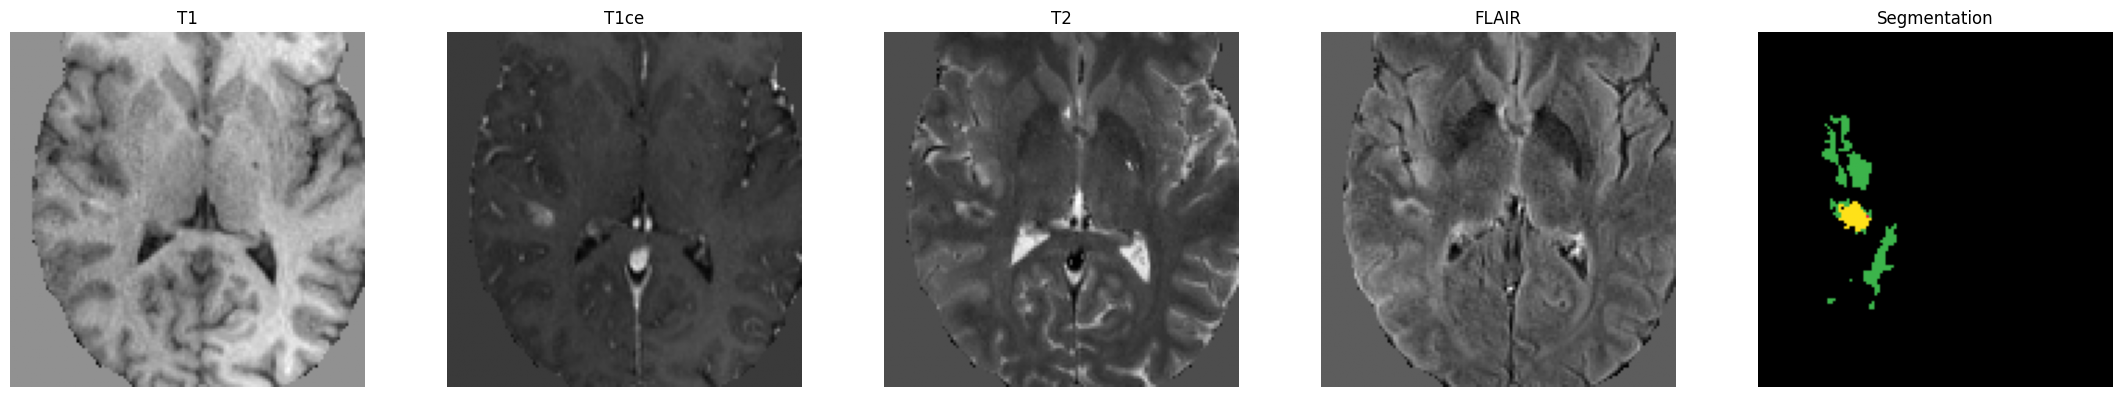

In [13]:
def show_training_patch(batch, sample_idx=0, slice_idx=64):
    """Visualize a single training patch."""
    img = batch["image"][sample_idx].cpu().numpy()   # (4, D, H, W)
    seg = batch["seg"][sample_idx].cpu().numpy()     # (D, H, W)

    titles = ["T1", "T1ce", "T2", "FLAIR", "Segmentation"]
    seg_cmap = ListedColormap(["black", "#e6194b", "#3cb44b", "#ffe119"])

    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    for i in range(4):
        axes[i].imshow(img[i, :, :, slice_idx].T, cmap="gray", origin="lower")
        axes[i].set_title(titles[i])
        axes[i].axis("off")

    axes[4].imshow(seg[:, :, slice_idx].T, cmap=seg_cmap,
                   origin="lower", vmin=0, vmax=3)
    axes[4].set_title("Segmentation")
    axes[4].axis("off")

    plt.tight_layout()
    plt.show()

show_training_patch(sample_batch)